# Install and Import Dependencies


In [1]:
!pip install insightface

# Current transformers 4.40 does not have text_model inside CLIPTextModel
# The repo has a dependencies files Arc2Face/requirements.txt.
# Couldn't install from the rqmnts text. Some subprocess fails or whatever
# Manually installed transformers==4.36.0.
# Added diffusers to the mix. Current version is incompatible. Installed diffusers==0.29.2
# Current peft installation is incompatible. Version number is not mentined in the rqmnts.
# Tried installing 0.7.1, 0.8.2, 0.9.0, 0.10.0
# !pip install -r /content/Arc2Face/requirements.txt
!pip install transformers==4.36.0 diffusers==0.29.2 gradio==5.7.1 sentence-transformers==2.2.2

# retrying peft installation by uninstalling it then re-installing it at 0.10.0
# retried again at 0.11.0
# Another issue was probably "stale runtime". I started a new session and my problem was solved. Hahaha...
!pip uninstall -y peft
!rm -rf /usr/local/lib/python3.13/dist-packages/peft
!rm -rf /usr/local/lib/python3.13/dist-packages/peft-*.dist-info
!pip install peft==0.11.0

# I could not find arc2face package in PyPl.
# Trying to downlaod from other sources. Checking the paper for "arc2face" source repo

!git clone https://github.com/foivospar/Arc2Face.git /content/Arc2Face


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 37.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.

In [2]:
!pip show transformers diffusers peft huggingface_hub

Name: transformers
Version: 4.36.0
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.13/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: peft, sentence-transformers
---
Name: diffusers
Version: 0.29.2
Summary: State-of-the-art diffusion in PyTorch and JAX.
Home-page: https://github.com/huggingface/diffusers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/diffusers/graphs/contributors)
Author-email: diffusers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.13/dist-packages
Re

In [3]:
import torch
import os
import sys
import glob
import zipfile
import pathlib
from insightface.app import FaceAnalysis
from PIL import Image
from pathlib import Path
import numpy as np

In [4]:
# Define providers dynamically based on CUDA availability
providers = ['CPUExecutionProvider']
if torch.cuda.is_available():
    providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
model_root = './' # ----
zip_path = f"{model_root}models/antelopev2.zip" # ----
extract_folder = f"{model_root}models/" # ----

try:                                                                        # ----
    FaceAnalysis(name='antelopev2', root=model_root, providers=providers)   # ----
    # FaceAnalysis(name='buffalo_l', root=model_root, providers=providers)    # ----
except AssertionError:                                                      # ----
    print("Error during zip extraction. Rectification in following steps")  # ----
    !rm -rf /content/models/antelopev2
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder) # ----
    print(f"Extracted {zip_path} to {extract_folder}/") # ----


download_path: ./models/antelopev2


100%|██████████| 352210/352210 [00:11<00:00, 31043.83KB/s]


Error during zip extraction. Rectification in following steps
Extracted ./models/antelopev2.zip to ./models//


In [5]:
# This snippet downloads the pretrained weights for Arc2Face Application. Found this on hugging face.
from huggingface_hub import hf_hub_download

hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arc2face/config.json", local_dir="./models")
hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arc2face/diffusion_pytorch_model.safetensors", local_dir="./models")
hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="encoder/config.json", local_dir="./models")
hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="encoder/pytorch_model.bin", local_dir="./models")

hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arcface.onnx", local_dir="./models/antelopev2")
!rm -rf /content/models/antelopev2/glintr100.onnx

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

arc2face/diffusion_pytorch_model.safeten(…):   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

encoder/pytorch_model.bin:   0%|          | 0.00/492M [00:00<?, ?B/s]

arcface.onnx:   0%|          | 0.00/261M [00:00<?, ?B/s]

In [6]:
sys.path.append('./Arc2Face')

# StyleGAN3 Image And Template Generation


In [33]:
# --- 1. StyleGAN3 ----------------------------------------------------------
!git clone https://github.com/NVlabs/stylegan3.git


# --- 2. The ONLY Python 3.12+ breakage in the repo -------------------------
from pathlib import Path
u = Path('/content/stylegan3/dnnlib/util.py')
s = u.read_text()
old = 'from distutils.util import strtobool'
new = '''try:
    from distutils.util import strtobool
except ImportError:  # distutils removed in Python 3.12
    def strtobool(val):
        val = str(val).lower()
        if val in ("y", "yes", "t", "true", "on", "1"):
            return 1
        if val in ("n", "no", "f", "false", "off", "0"):
            return 0
        raise ValueError(f"invalid truth value {val!r}")'''
if old in s:
    u.write_text(s.replace(old, new))
    print("patched dnnlib/util.py")
else:
    print("already patched")


# --- 3. Deps (scipy/numpy versions are fine as-is; do NOT downgrade) -------
!pip install -q click requests imageio ninja
!pip install -q insightface onnxruntime-gpu

fatal: destination path 'stylegan3' already exists and is not an empty directory.
patched dnnlib/util.py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 1.7 MB/s eta 0:00:00


In [36]:
# ============================================================
# Cell 2 — Config, imports, StyleGAN3 op dispatch
# ============================================================
import sys, json, numpy as np, torch
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

REPO        = '/content/stylegan3'
MODELS_ROOT = '/content'                                   # contains models/antelopev2
OUT_DIR     = '/content/output/StyleGAN3Templates'         # -> FaceCloak folder_path
IMG_DIR     = '/content/StyleGAN3Output'                   # or None to skip PNGs

NUM_TEMPLATES = 20
START_SEED    = 0
PSI           = 0.7        # paper: truncation factor psi = 0.7
BATCH         = 8          # latents per generator forward
DET_SIZE      = 256
NORMALIZE     = False      # see note below
OPS           = 'auto'     # 'auto' | 'cuda' | 'ref'

NGC = "https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files"
PKL = f"{NGC}/stylegan3-t-ffhqu-256x256.pkl"
# alternatives: stylegan3-r-ffhqu-256x256.pkl | stylegan3-r-ffhq-1024x1024.pkl
#               stylegan3-t-ffhq-1024x1024.pkl | stylegan3-r-ffhqu-1024x1024.pkl

sys.path.insert(0, REPO)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

# StyleGAN3's _init() RAISES when the CUDA plugin won't build -- it does not
# return False -- so the pure-PyTorch fallback is NOT automatic. Rebind it.
from torch_utils.ops import bias_act, upfirdn2d, filtered_lrelu
_MODS = (bias_act, upfirdn2d, filtered_lrelu)

def _force_ref():
    for m in _MODS:
        m._init = lambda: False

if OPS == 'ref' or device.type == 'cpu':
    _force_ref(); print('ops: reference (pure PyTorch)')
elif OPS == 'cuda':
    print('ops: cuda (forced)')
else:
    try:
        _x = torch.randn(1, 4, 8, 8, device='cuda')
        bias_act.bias_act(_x, impl='cuda')
        filtered_lrelu.filtered_lrelu(_x, impl='cuda')
        print('ops: cuda (compiled)')
    except Exception as e:
        print(f'ops: CUDA plugin unavailable ({type(e).__name__}: {str(e)[:100]})')
        print('     -> pure-PyTorch reference ops (slower, numerically identical)')
        _force_ref()

device: cuda | Tesla T4


/content/stylegan3/torch_utils/ops/conv2d_gradfix.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Setting up PyTorch plugin "bias_act_plugin"... Failed!
ops: CUDA plugin unavailable (ModuleNotFoundError: No module named 'bias_act_plugin')
     -> pure-PyTorch reference ops (slower, numerically identical)


In [37]:
# ============================================================
# Cell 3 — Load StyleGAN3 generator + InsightFace
# ============================================================
import dnnlib, legacy
from insightface.app import FaceAnalysis

# --- guard against the embedding-space bug -------------------------------
_pack = Path(MODELS_ROOT) / 'models' / 'antelopev2'
_onnx = sorted(p.name for p in _pack.glob('*.onnx'))
print('antelopev2/:', _onnx)
assert 'arcface.onnx' in _onnx, (
    "arcface.onnx missing. Arc2Face/FaceCloak use ArcFace trained on WebFace42M; "
    "insightface's glintr100.onnx is a DIFFERENT net with an unaligned 512-d space. "
    "Re-run Cell 1.")
if 'glintr100.onnx' in _onnx:
    print('WARNING: glintr100.onnx still present -- delete it.')

app = FaceAnalysis(name='antelopev2', root=MODELS_ROOT,
                   providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0 if device.type == 'cuda' else -1, det_size=(DET_SIZE, DET_SIZE))
_rec = app.models.get('recognition')
print('recognition ->', type(_rec).__name__, '| input', getattr(_rec, 'input_shape', None))

# --- generator ------------------------------------------------------------
print('loading', PKL.rsplit('/', 1)[-1])
with dnnlib.util.open_url(PKL) as f:
    G = legacy.load_network_pkl(f)['G_ema']
G = G.to(device).eval().requires_grad_(False)
print(f'G: z_dim={G.z_dim} c_dim={G.c_dim} img={G.img_resolution}x{G.img_resolution}')


@torch.no_grad()
def synth_batch(seeds):
    """seeds -> (N, H, W, 3) uint8 RGB"""
    z = torch.from_numpy(
        np.stack([np.random.RandomState(int(s)).randn(G.z_dim) for s in seeds])
    ).to(device).float()
    c = torch.zeros([len(seeds), G.c_dim], device=device)
    img = G(z, c, truncation_psi=PSI, noise_mode='const')
    img = (img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8)
    return img.cpu().numpy()


def extract(rgb):
    """rgb HxWx3 uint8 -> (512,) float32 or None. InsightFace wants BGR."""
    bgr = np.ascontiguousarray(rgb[:, :, ::-1])   # contiguous: ORT dislikes neg strides
    faces = app.get(bgr)
    if not faces:
        return None
    f = max(faces, key=lambda x: (x['bbox'][2] - x['bbox'][0]) * (x['bbox'][3] - x['bbox'][1]))
    return np.asarray(f['embedding'], dtype=np.float32)

antelopev2/: ['1k3d68.onnx', '2d106det.onnx', 'arcface.onnx', 'genderage.onnx', 'scrfd_10g_bnkps.onnx']


/usr/local/lib/python3.13/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:197: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


recognition -> ArcFaceONNX | input ['None', 3, 112, 112]
loading stylegan3-t-ffhqu-256x256.pkl
G: z_dim=512 c_dim=0 img=256x256


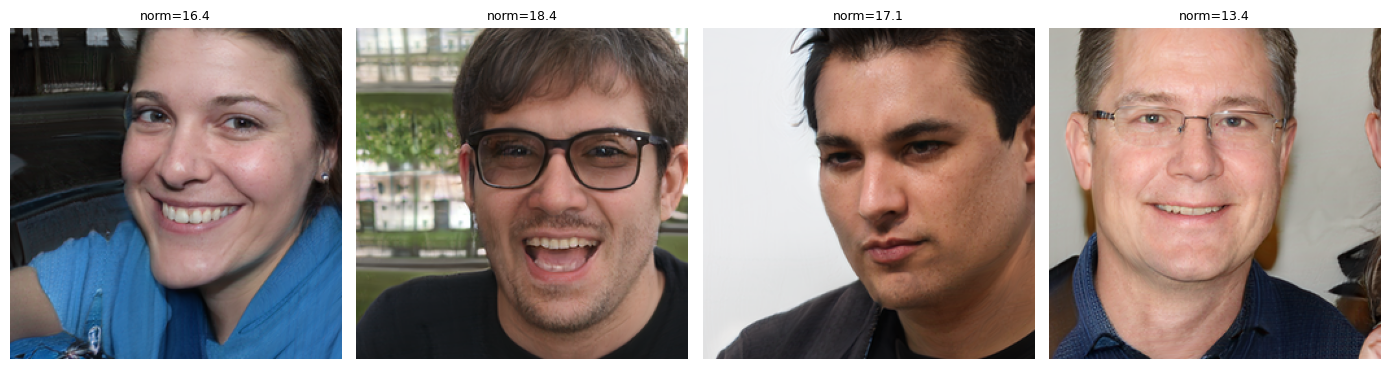

detected 4/4
pairwise cosine between DIFFERENT synthetic identities:
[[ 1.    -0.007  0.034  0.078]
 [-0.007  1.     0.058  0.083]
 [ 0.034  0.058  1.     0.144]
 [ 0.078  0.083  0.144  1.   ]]
off-diagonal mean = 0.065
EXPECTED ~0.0-0.15. If you see ~0.6+, the recognition model is wrong (that is the glintr100 signature from your Arc2Face run).


In [38]:
# ============================================================
# Cell 4 — Sanity check (4 faces + embedding stats)
# ============================================================
import matplotlib.pyplot as plt

_imgs = synth_batch([0, 1, 2, 3])
_embs = [extract(im) for im in _imgs]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, im, e in zip(axes, _imgs, _embs):
    ax.imshow(im); ax.axis('off')
    ax.set_title('no face' if e is None else f'norm={np.linalg.norm(e):.1f}', fontsize=9)
plt.tight_layout(); plt.show()

_ok = [e for e in _embs if e is not None]
print(f'detected {len(_ok)}/4')
if len(_ok) >= 2:
    _n = np.stack([e / np.linalg.norm(e) for e in _ok])
    _c = _n @ _n.T
    print('pairwise cosine between DIFFERENT synthetic identities:')
    print(np.round(_c, 3))
    _off = _c[~np.eye(len(_n), dtype=bool)]
    print(f'off-diagonal mean = {_off.mean():.3f}')
    print('EXPECTED ~0.0-0.15. If you see ~0.6+, the recognition model is wrong '
          '(that is the glintr100 signature from your Arc2Face run).')

In [39]:
# ============================================================
# Cell 5 — Generate (resumable: re-run after a disconnect)
# ============================================================
out = Path(OUT_DIR); out.mkdir(parents=True, exist_ok=True)
img_dir = Path(IMG_DIR) if IMG_DIR else None
if img_dir: img_dir.mkdir(parents=True, exist_ok=True)

fail_path = out / '_no_face_seeds.json'
failed = set(json.loads(fail_path.read_text())) if fail_path.exists() else set()
have   = {int(p.stem.split('_')[1]) for p in out.glob('synth_*.npy')}
print(f'existing: {len(have)} templates, {len(failed)} known no-face seeds')

need, seed = NUM_TEMPLATES - len(have), START_SEED
pbar = tqdm(total=max(need, 0), desc='templates')
new = 0

while new < need:
    batch = []
    while len(batch) < BATCH:
        if seed not in have and seed not in failed:
            batch.append(seed)
        seed += 1

    for s, rgb in zip(batch, synth_batch(batch)):
        emb = extract(rgb)
        if emb is None:
            failed.add(s); continue
        if NORMALIZE:
            emb = emb / np.linalg.norm(emb)
        np.save(out / f'synth_{s:06d}.npy', emb[None].astype(np.float32))  # (1, 512)
        if img_dir:
            Image.fromarray(rgb).save(img_dir / f'synth_{s:06d}.png')
        new += 1; pbar.update(1)
        if new >= need: break

    fail_path.write_text(json.dumps(sorted(failed)))

pbar.close()
print(f'\ndone: {len(list(out.glob("synth_*.npy")))} templates in {out}')
print(f'no-face skips: {len(failed)} | next free seed: {seed}')

existing: 0 templates, 0 known no-face seeds


templates:   0%|          | 0/20 [00:00<?, ?it/s]


done: 20 templates in /content/output/StyleGAN3Templates
no-face skips: 0 | next free seed: 24


In [ ]:
# ============================================================
# Cell 6 — Verify
# ============================================================
files = sorted(Path(OUT_DIR).glob('synth_*.npy'))
T = np.stack([np.load(f)[0] for f in files])
print(f'{len(files)} templates | stacked {T.shape} {T.dtype}')
print(f'L2 norms: min={np.linalg.norm(T,axis=1).min():.2f} '
      f'mean={np.linalg.norm(T,axis=1).mean():.2f} '
      f'max={np.linalg.norm(T,axis=1).max():.2f}')

sample = np.load(files[0])
print(f'per-file shape {sample.shape}  <- must be (1, 512) for torch.cat in FaceCloak')

N = T / np.linalg.norm(T, axis=1, keepdims=True)
idx = np.random.RandomState(0).choice(len(N), size=min(500, len(N)), replace=False)
C = N[idx] @ N[idx].T
off = C[~np.eye(len(idx), dtype=bool)]

plt.figure(figsize=(6, 3.2))
plt.hist(off, bins=80)
plt.axvline(off.mean(), ls='--', c='k', lw=1, label=f'mean={off.mean():.3f}')
plt.xlabel('cosine between distinct synthetic identities'); plt.ylabel('count')
plt.legend(); plt.tight_layout(); plt.show()
print(f'mean={off.mean():.4f}  p99={np.percentile(off, 99):.4f}  max={off.max():.4f}')
print('Healthy: mean near 0, p99 well under ~0.3.')

In [40]:
!zip -r /content/StyleGAN3Images.zip /content/StyleGAN3Outout/

  adding: content/StyleGAN3Outout/ (stored 0%)
  adding: content/StyleGAN3Outout/synth_000007.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000008.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000015.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000010.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000016.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000014.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000017.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000000.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000019.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000009.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000011.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000013.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000006.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000003.png (deflated 0%)
  adding: content/StyleGAN3Outout/synth_000

In [41]:
!zip -r StyleGAN3Templates.zip /content/output/StyleGAN3Templates/

  adding: content/output/StyleGAN3Templates/ (stored 0%)
  adding: content/output/StyleGAN3Templates/synth_000013.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000011.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000002.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000010.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000016.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000001.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000007.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000004.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000006.npy (deflated 8%)
  adding: content/output/StyleGAN3Templates/synth_000019.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000003.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates/synth_000018.npy (deflated 7%)
  adding: content/output/StyleGAN3Templates

# Template Generation


/usr/local/lib/python3.13/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:197: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


2
<class 'list'>
0 /content/mrpedo.jpg


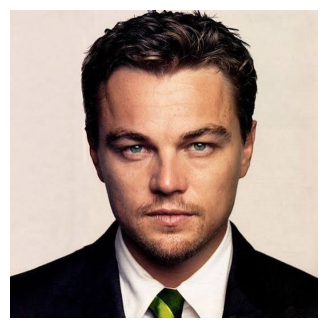

1 /content/tahmeed.jpg


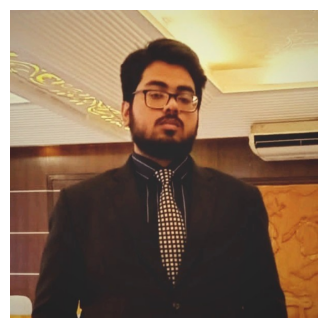

In [43]:
# Updated the root argument
#### IT UNZIPPED ANYWAY ####
# It won't unzip if the damn thing already exists.
app = FaceAnalysis(name='antelopev2', root=model_root, providers=providers)
# app = FaceAnalysis(name='buffalo_l', root=model_root, providers=providers)
app.prepare(ctx_id=0, det_size=(640, 640))

# Updated the root argument
app2 = FaceAnalysis(name='antelopev2', root=model_root, providers=providers)
# app2 = FaceAnalysis(name='buffalo_l', root=model_root, providers=providers)
app2.prepare(ctx_id=0, det_size=(480,480))
## Arguments

# image_path = str(sys.argv[1]) # folder path to images
# output_path = str(sys.argv[2]) # folder path to save outputs
# startind = int(sys.argv[3]) # starting index of files to process
# dataset_name = str(sys.argv[4]) # dataset_name = ['lfw', 'cfpfp']
# image_path = '/content/1744362020887.jpg'
image_path = '/content'
output_path = '/content/output'
startind = 0
dataset_name = 'lfw'

# get image and its embedding
if dataset_name == 'lfw': # There was a mistake in this line, lmao.
    targetfiles = sorted(glob.glob(f'{image_path}/*.jpg')) # /path-to-lfw-data-folder/00001.jpg
else:
    targetfiles = sorted(glob.glob(f'{image_path}/**/*/*.jpg'))  # /path-to-cfp-dataset/Data/Images/001/frontal/01.jpg
print(len(targetfiles))
print(type(targetfiles))
# save face templates

save_path_npy = f"{output_path}/InsightFaceTemplates"
os.makedirs(save_path_npy, exist_ok=True)


for imgid, img in enumerate(targetfiles[startind:], start=startind):
    fname1= pathlib.PurePath(str(img))
    print(imgid, fname1)
    imgid_target = Path(str(fname1)).stem
    if dataset_name == 'lfw':
        try:
            img_target = np.array(Image.open(str(fname1)))[:,:,::-1]
            show(img_target)
            try:
                faces_target = app.get(img_target)
                faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
            except:
                faces_target = app2.get(img_target)
                faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)

            id_emb_target = torch.tensor(faces_target['embedding'], dtype=torch.float16)[None]
            # save outputs
            id_emb_nparr = id_emb_target.detach().cpu().numpy()
            np.save(f'{save_path_npy}/{imgid_target}.npy', id_emb_nparr)
        except:
            continue
    else:
        pathnm1 = str(fname1).split('/') # /path to cfp-dataset/Data/Images/001/frontal/01.jpg
        subid_target = pathnm1[12] # change the index in square bracketes depending on where your cfpfp images are saved. Example subid_target='001'
        laterality = pathnm1[13] # change the index in square bracketes depending on where your cfpfp images are saved. Example laterality='frontal'

        if laterality=='frontal':
            try:
                img_target = np.array(Image.open(str(fname1)))[:,:,::-1]
                show(img_target)
                try:
                    faces_target = app.get(img_target)
                    faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
                except:
                    faces_target = app2.get(img_target)
                    faces_target = sorted(faces_target, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)

                id_emb_target = torch.tensor(faces_target['embedding'], dtype=torch.float16)[None]
                # save outputs
                id_emb_nparr = id_emb_target.detach().cpu().numpy()
                np.save(f'{save_path_npy}/SubID_{subid_target}_ImgID_{imgid_target}_{laterality}.npy', id_emb_nparr)

            except:
                continue

In [8]:

# ## Extract templates using ArcFace finetuned with Orthogonal Projection Loss. Follow the InsightFace repo instructions and put model.pt in models_zoo

# # import argparse

# import cv2
# import numpy as np
# import torch

# from backbones import get_model


# @torch.no_grad()
# def inference(weight, name, img):
#     if img is None:
#         img = np.random.randint(0, 255, size=(112, 112, 3), dtype=np.uint8)
#     else:
#         img = cv2.imread(img)
#         img = cv2.resize(img, (112, 112))

#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     img = np.transpose(img, (2, 0, 1))
#     img = torch.from_numpy(img).unsqueeze(0).float()
#     img.div_(255).sub_(0.5).div_(0.5)
#     net = get_model(name, fp16=False)
#     net.load_state_dict(torch.load(weight, map_location=torch.device('cpu')))
#     net.eval()
#     feat = net(img).numpy()
#     # save the feat
#     np.save('img_name.npy',feat)


# inference(args.weight, args.network, args.img)

# Template 2 Face

In [9]:
# Found the source repo. Cloned it into the environment.
# Linked their asses to the notebook.
from arc2face.models import CLIPTextModelWrapper
from arc2face.utils import project_face_embs

/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.13/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def show(img, title=None, bgr=None, figsize=(4, 4)):
    """Display a PIL Image or numpy array inline."""
    if isinstance(img, Image.Image):
        arr = np.array(img)
    else:
        arr = np.asarray(img)

    # cv2 loads BGR; auto-detect if not told
    if bgr is None:
        bgr = not isinstance(img, Image.Image) and arr.ndim == 3 and arr.shape[2] == 3
    if bgr and arr.ndim == 3 and arr.shape[2] == 3:
        arr = arr[:, :, ::-1]

    # normalize float arrays outside [0, 1]
    if np.issubdtype(arr.dtype, np.floating):
        lo, hi = float(arr.min()), float(arr.max())
        if lo < 0 or hi > 1:
            arr = (arr - lo) / (hi - lo + 1e-8)

    plt.figure(figsize=figsize)
    plt.imshow(arr.squeeze(), cmap="gray" if arr.squeeze().ndim == 2 else None)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

In [11]:
from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

# from arc2face import CLIPTextModelWrapper, project_face_embs

import torch
import os
import sys
import glob
import pathlib
from pathlib import Path
import random
from insightface.app import FaceAnalysis
from PIL import Image
import numpy as np

base_model = 'runwayml/stable-diffusion-v1-5'

## Arc2Face
encoder = CLIPTextModelWrapper.from_pretrained(
    'models', subfolder="encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    'models', subfolder="arc2face", torch_dtype=torch.float16
)

pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None
    )

app = FaceAnalysis(name='antelopev2', root='./', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(480, 480))

app2 = FaceAnalysis(name='antelopev2', root='./', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app2.prepare(ctx_id=0, det_size=(640,640))

cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
##########
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
/usr/local/lib/python3.13/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:197: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


In [44]:

templatepath =  '/content/output/InsightFaceTemplates'
templates = sorted(glob.glob(f'{templatepath}/*.npy'))
print(len(templates))


2


In [13]:
## positive disruptor generation
def add_noise(embedding, std=0.2):
    #noise = (var**0.5)*torch.randn(embedding.shape, dtype=torch.float16).cuda()
    #return embedding + noise
    return embedding + torch.randn_like(embedding) * std

def feature_dropout(embedding, p=0.8):
    mask = torch.bernoulli(torch.ones_like(embedding) * p)
    return embedding * mask


## negative feature/orthogonal disruptor generation
def gram_schmidt(v):
    """
    Finds an orthogonal vector to the given vector using the Gram-Schmidt process.
    """

    u = torch.randn_like(v)  # Generate a random vector of the same size
    u = u - (torch.dot(u, v) / torch.dot(v, v)) * v
    #return u / torch.norm(u)
    return u

def synth_neg(folder_path):
   # List all files in the folder
    files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

    # Choose a random file
    random_file = random.choice(files)

    # Construct the full path to the file
    file_path = os.path.join(folder_path, random_file)
    synth = torch.from_numpy(np.load(f"{file_path}", allow_pickle=True))
    synth = synth.to(torch.float16).cuda()
    return synth


In [45]:
print(len(templates))

2


0


  0%|          | 0/25 [00:00<?, ?it/s]

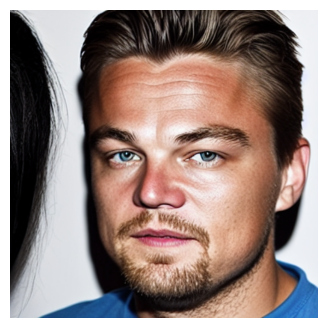

cosine noisy: tensor([0.9741], device='cuda:0', dtype=torch.float16)


  0%|          | 0/25 [00:00<?, ?it/s]

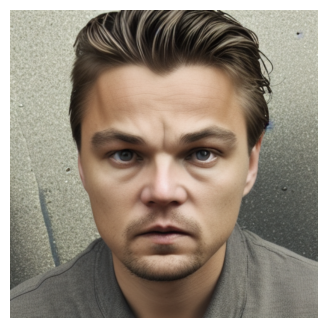

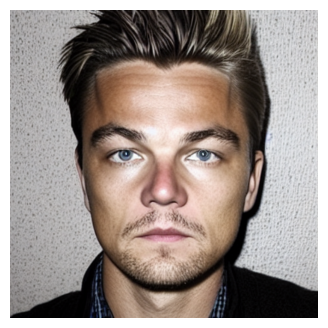

  0%|          | 0/25 [00:00<?, ?it/s]

cosine mask: tensor([0.9146], device='cuda:0', dtype=torch.float16)


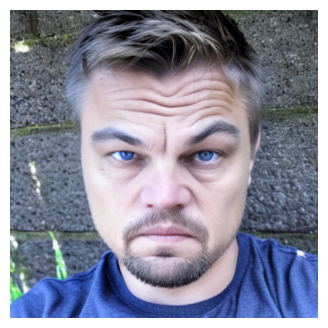

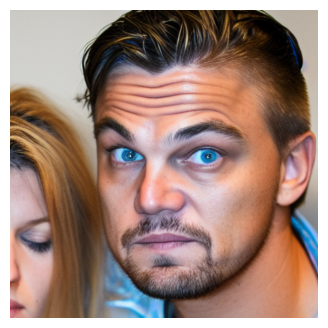

  0%|          | 0/25 [00:00<?, ?it/s]

cosine ortho: tensor([3.2842e-05], device='cuda:0', dtype=torch.float16)


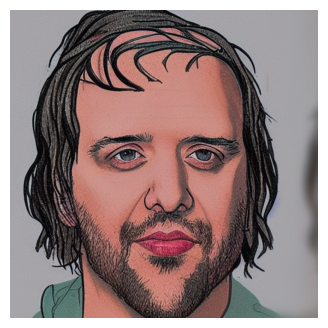

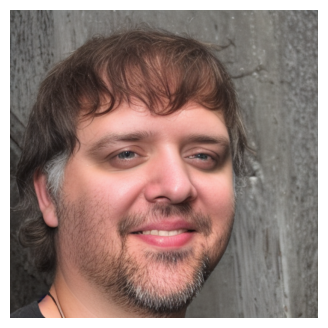

  0%|          | 0/25 [00:00<?, ?it/s]

cosine synth: tensor([0.0100], device='cuda:0', dtype=torch.float16)


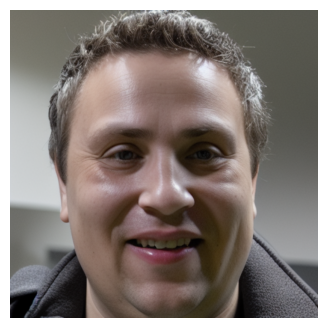

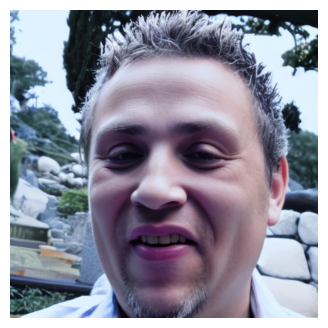

1


  0%|          | 0/25 [00:00<?, ?it/s]

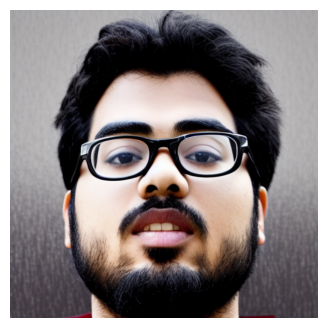

cosine noisy: tensor([0.9834], device='cuda:0', dtype=torch.float16)


  0%|          | 0/25 [00:00<?, ?it/s]

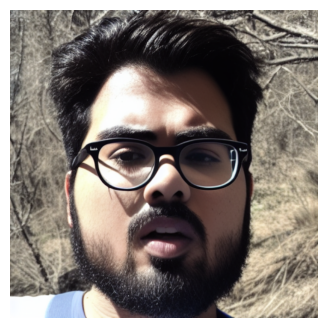

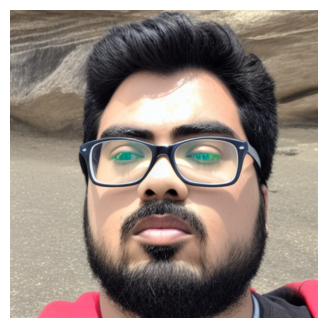

  0%|          | 0/25 [00:00<?, ?it/s]

cosine mask: tensor([0.9146], device='cuda:0', dtype=torch.float16)


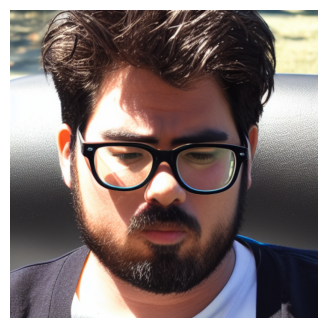

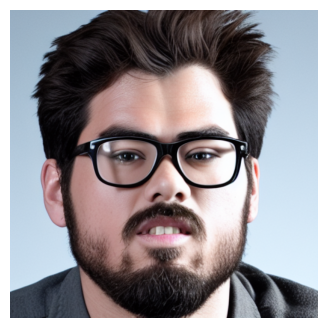

  0%|          | 0/25 [00:00<?, ?it/s]

cosine ortho: tensor([-5.5432e-06], device='cuda:0', dtype=torch.float16)


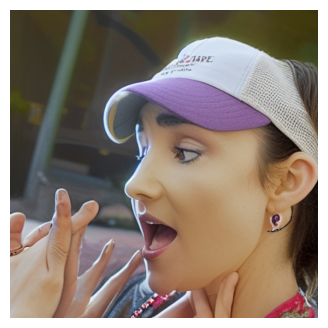

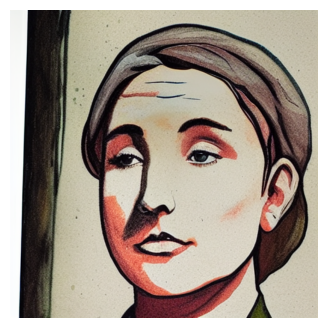

  0%|          | 0/25 [00:00<?, ?it/s]

cosine synth: tensor([0.0428], device='cuda:0', dtype=torch.float16)


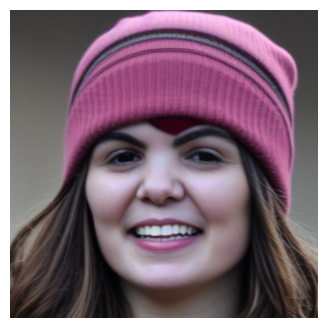

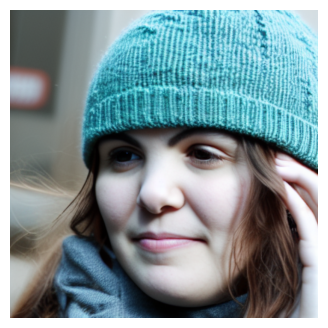

In [46]:

folder_path = '/content/output/StyleGAN3Templates'
# save outputs
# save_path = f"/path-to-save-generatedimages"
# os.makedirs(save_path, exist_ok=True)
num_images = 2 # here, 2 images are shown for example, you can select 4/6...
for ind, tempfile in enumerate(templates):
    print(ind)
    id_emb_target = torch.from_numpy(np.load(f"{tempfile}", allow_pickle=True)).cuda()
    fname= pathlib.PurePath(str(tempfile))
    filename = Path(str(fname)).stem

    ## reconstruct original template
    template = id_emb_target.to(torch.float16)
    template = id_emb_target/torch.norm(id_emb_target, dim=1, keepdim=True)   # normalize embedding
    id_emb_template = project_face_embs(pipeline, template)    # pass through the encoder
    image = pipeline(prompt_embeds=id_emb_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=1).images
    # image[0].save(f"{save_path}/{filename}_template_InsightFace.png")
    show(image[0])

    ## reconstruct positive disruptors

    # noise
    id_emb_noisy = add_noise(id_emb_target)# add noise to id_emb_target not template
    id_emb_noisy = id_emb_noisy/torch.norm(id_emb_noisy, dim=1, keepdim=True)   # normalize noisy embedding
    id_emb_noisy_project = project_face_embs(pipeline, id_emb_noisy)
    print('cosine noisy:',cos(template, id_emb_noisy))
    images_noisy = pipeline(prompt_embeds=id_emb_noisy_project, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    for id, img in enumerate(images_noisy):

        # img.save(f"{save_path}/{filename}_{id}_customnoise_InsightFace.png")
        show(img)
    # mask
    pos_mask = feature_dropout(id_emb_target)
    pos_mask = pos_mask/torch.norm(pos_mask, dim=1, keepdim=True)
    id_emb_mask_template = project_face_embs(pipeline, pos_mask)    # pass through the encoder
    images_mask = pipeline(prompt_embeds=id_emb_mask_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    print('cosine mask:',cos(template, pos_mask))
    for id, img in enumerate(images_mask):

        # img.save(f"{save_path}/{filename}_{id}_custommask_InsightFace.png")
        show(img)

    ## reconstruct negative disruptors
    # orthognal
    neg_ortho = gram_schmidt(torch.squeeze(id_emb_target,0))
    neg_ortho = torch.unsqueeze(neg_ortho,0)
    neg_ortho = neg_ortho/torch.norm(neg_ortho, dim=1, keepdim=True)
    id_emb_ortho_template = project_face_embs(pipeline, neg_ortho)    # pass through the encoder
    images_ortho = pipeline(prompt_embeds=id_emb_ortho_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    print('cosine ortho:',cos(template, neg_ortho))
    for id, img in enumerate(images_ortho):

        # img.save(f"{save_path}/{filename}_{id}_customortho_InsightFace.png")
        show(img)

    # synthetic
    neg_synth = synth_neg(folder_path)
    neg_synth = neg_synth/torch.norm(neg_synth, dim=1, keepdim=True)
    id_emb_synth_template = project_face_embs(pipeline, neg_synth)    # pass through the encoder
    images_synth = pipeline(prompt_embeds=id_emb_synth_template, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=num_images).images
    print('cosine synth:',cos(template, neg_synth))
    for id, img in enumerate(images_synth):

        # img.save(f"{save_path}/{filename}_{id}_customsynth_InsightFace.png")
        show(img)

In [16]:
from transformers import CLIPTextModel
import inspect

# Class-level check — expect False. Not evidence of anything.
print(hasattr(CLIPTextModel, "text_model"))

# What's actually in __init__
print(inspect.getsource(CLIPTextModel.__init__))

# Where the file lives, if you want to read it
print(inspect.getfile(CLIPTextModel))

False
    def __init__(self, config: CLIPTextConfig):
        super().__init__(config)
        self.text_model = CLIPTextTransformer(config)
        # Initialize weights and apply final processing
        self.post_init()

/usr/local/lib/python3.13/dist-packages/transformers/models/clip/modeling_clip.py


In [17]:
from transformers import CLIPTextModel
m = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
print(hasattr(m, "text_model"))
print([n for n, _ in m.named_children()])

/usr/local/lib/python3.13/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

True
['text_model']


# Directly from Hugging Face

In [18]:
from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

from arc2face import CLIPTextModelWrapper, project_face_embs

import torch
from insightface.app import FaceAnalysis
from PIL import Image
import numpy as np

# Arc2Face is built upon SD1.5
# The repo below can be used instead of the now deprecated 'runwayml/stable-diffusion-v1-5'
base_model = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

encoder = CLIPTextModelWrapper.from_pretrained(
    'models', subfolder="encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    'models', subfolder="arc2face", torch_dtype=torch.float16
)

pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None
    )
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

vocab.json: 0.00B [00:00, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_bbox(img, bboxes, bgr=False, kps=None, figsize=(5, 5)):
    """Draw insightface bboxes [x1, y1, x2, y2] over an image."""
    arr = np.asarray(img)
    if bgr and arr.ndim == 3 and arr.shape[2] == 3:
        arr = arr[:, :, ::-1]

    bboxes = np.atleast_2d(np.asarray(bboxes, dtype=float))

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(arr)

    for i, (x1, y1, x2, y2) in enumerate(bboxes[:, :4]):
        ax.add_patch(patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none"))
        ax.text(x1, y1 - 4, str(i), color="lime",
                fontsize=10, weight="bold")

    if kps is not None:
        kps = np.asarray(kps).reshape(-1, 5, 2)
        for k in kps:
            ax.scatter(k[:, 0], k[:, 1], s=18, c="red", marker="x")

    ax.axis("off")
    plt.show()

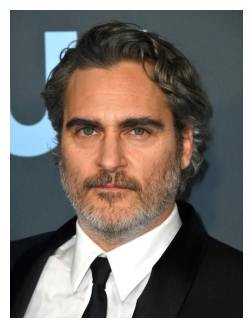

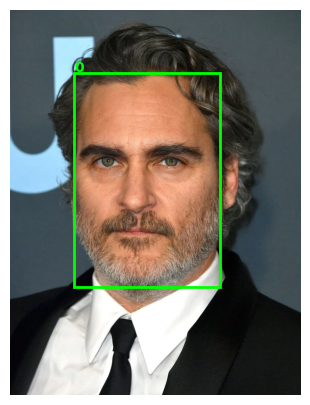

In [20]:
app = FaceAnalysis(name='antelopev2', root='./', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

img = np.array(Image.open('/content/joacquin.png'))
show(img, bgr=False)

faces = app.get(img)
faces = sorted(faces, key=lambda x:(x['bbox'][2]-x['bbox'][0])*(x['bbox'][3]-x['bbox'][1]))[-1]  # select largest face (if more than one detected)
id_emb = torch.tensor(faces['embedding'], dtype=torch.float16)[None].cuda()
id_emb = id_emb/torch.norm(id_emb, dim=1, keepdim=True)   # normalize embedding
id_emb = project_face_embs(pipeline, id_emb)    # pass through the encoder

show_bbox(img, faces['bbox'], bgr=False)


In [21]:
num_images = 4
images = pipeline(prompt_embeds=id_emb, num_inference_steps=25, guidance_scale=1.0, num_images_per_prompt=num_images).images

  0%|          | 0/25 [00:00<?, ?it/s]

4


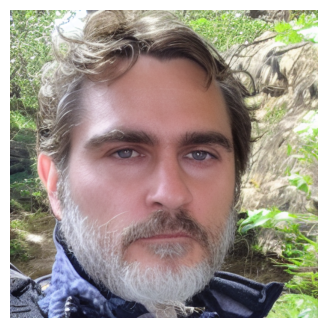

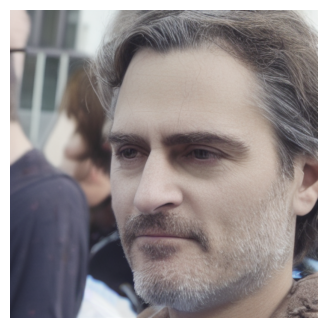

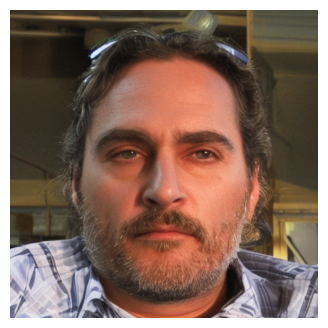

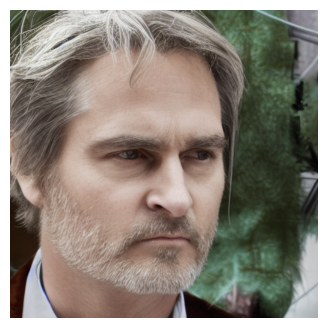

In [22]:
print(len(images))
for image in images:
  show(image)

In [23]:
print(type(faces))
print(len(faces))
print(faces['bbox'])

<class 'insightface.app.common.Face'>
9
[ 266.4796   259.8991   872.04224 1151.3789 ]


# FaceCloak Playground

## Face Cloak Implementation

In [25]:
!git clone https://github.com/sudban3089/FaceCloak.git

Cloning into 'FaceCloak'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 246 (delta 48), reused 4 (delta 4), pack-reused 149 (from 1)
Receiving objects: 100% (246/246), 4.47 MiB | 3.71 MiB/s, done.
Resolving deltas: 100% (113/113), done.


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
import os
import sys
import pathlib
from pathlib import Path
import glob
import pickle
import time
import numpy as np
from torchmetrics import HammingDistance

ModuleNotFoundError: No module named 'torchmetrics'

In [ ]:
class TemplateDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels


    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]


        return feature, label

In [ ]:
## positive disruptor generation
# std and p values follow paper
def add_noise(embedding, std=0.2):
    return embedding + torch.randn_like(embedding) * std

def feature_dropout(embedding, p=0.8):
    mask = torch.bernoulli(torch.ones_like(embedding) * p)
    return embedding * mask

## negative disruptor/orthogonal disruptor generation
def gram_schmidt(v):
    # Finds an orthogonal vector to the given vector using the Gram-Schmidt process.
    u = torch.randn_like(v)  # Generate a random vector of the same size
    u = u - (torch.dot(u, v) / torch.dot(v, v)) * v
    #return u / torch.norm(u)
    return u

def synth_neg(folder_path):
   # List all files in the folder
    files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

    # Choose a random file
    random_file = random.choice(files)
    ###
    # either generate a random synthetic image using gen_images.py, then extract the template using script extracttemplate.py or
    # generate the synthetic images and extract the synthetic templates offline (saves time) and read a random template on the fly
    ###
    # Construct the full path to the file
    file_path = os.path.join(folder_path, random_file)
    synth = torch.from_numpy(np.load(f"{file_path}", allow_pickle=True))
    synth = synth.to(torch.float32)
    return synth

def min_hamming_distance_tensor(target_tensor, tensor_list):
    """
    Finds the tensor in the list with the minimum Hamming distance to the target tensor.

    Args:
        target_tensor (torch.Tensor): The reference tensor.
        tensor_list (list of torch.Tensor): The list of tensors to compare.

    Returns:
        torch.Tensor: The tensor with the minimum Hamming distance.
    """

    min_distance = float('inf')
    min_tensor = None

    for tensor in tensor_list:
        hamming_distance = torch.sum(target_tensor != tensor)
        if hamming_distance < min_distance:
            min_distance = hamming_distance
            min_tensor = tensor

    return min_tensor

## take n choose 2
def n_choose_2_pairs(tensor):
    """
    Takes a tensor of shape (n, d) and returns a tensor of shape (n*(n-1)/2, 2, d)
    containing all possible pairs of tensors.
    """
    n, d = tensor.shape
    indices = torch.combinations(torch.arange(n), 2)
    return torch.stack([tensor[indices[:, 0]], tensor[indices[:, 1]]], dim=1)

## triplet composition
def extract_tensors_by_label(tensors, labels, target_label):
    """
    Extracts tensors from a batch based on their corresponding labels.

    Args:
        tensors (torch.Tensor): A batch of tensors.
        labels (torch.Tensor): A tensor of labels corresponding to the tensors.
        target_label (int): The label to extract tensors for.

    Returns:
        torch.Tensor: A tensor containing the extracted tensors.
    """

    mask = labels == target_label
    return tensors[mask]

In [ ]:

# synthetic negative disruptors
folder_path = '/path/to/synthetic/StyleGAN3Templates'

gallery_path = str(sys.argv[1]) # filename1 from cfpfp_pair.txt or lfw_pair.txt
probe_path = str(sys.argv[2]) # filename2 from cfpfp_pair.txt or lfw_pair.txt
results_path = str(sys.argv[3]) # path to save results

num_epochs = int(sys.argv[4]) # default = 100
num_featureaug = int(sys.argv[5]) # default = 50 (so total 101 (=2 * 50 disruptors +1 unprotected template))
bit_size = int(sys.argv[6]) # default = 64
margin = float(sys.argv[7]) # default = 9.0

dataset_name = str(sys.argv[8) # default = 'lfw' Options: ['lfw', 'cfpfp']

os.makedirs(f"{results_path}/epoch_{num_epochs}_feataug_{num_featureaug}_hashsize_{bit_size}_TripletMarginwithDist_{margin}", exist_ok=True)

Traintime = []
Testtime = []
Enrollingtime = []
ModelSizes = []
gen_scores = []
imposter_scores = []

## Declare model class
class MyModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)

        self.fc2 = nn.Linear(hidden_size, output_size)
        self.bn2 = nn.BatchNorm1d(output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.tanh(x)

        return x


# Create an instance of the model
model = MyModel(512, 256, bit_size)
criterion = nn.MSELoss(reduction = 'mean')
criterion2 = nn.TripletMarginWithDistanceLoss(distance_function=nn.MSELoss(), margin=margin)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
HD = HammingDistance()

with open(f'/path/to/read/filename/{dataset_name}_pair.txt', 'r') as file:
    for ind, line in enumerate(file):
        #print(ind)

        data = line.strip().split()
        fname1 = str(data[0])
        fname2 = str(data[1])
        flag = int(data[2])

        galleryfilename = f"{gallery_path}/{fname1}"

        probefilename = f"{probe_path}/{fname2}"

        #print(galleryfilename, probefilename)
        if os.path.exists(galleryfilename) & os.path.exists(probefilename):
            template = torch.from_numpy(np.load(f"{galleryfilename}", allow_pickle=True))
            template = template.to(torch.float32)
            template = template/torch.norm(template, dim=1, keepdim=True)

            batch_size = num_featureaug*2
            idx = torch.randint(1,3, (num_featureaug,))

            ## Create positive disruptors
            pos_features=[]
            for id in idx:
                match id:
                    case 1:
                        pos = add_noise(template)
                    case 2:
                        pos = feature_dropout(template) #add_noise(template) #
                pos_features.append(pos)

            pos_features = torch.cat(pos_features, dim=0)
            pos_labels = torch.ones(num_featureaug) # positive feats --- label:1

            ## Create negative disruptors
            neg_features=[]
            for id in idx:
                match id:
                    case 1:
                        neg = gram_schmidt(torch.squeeze(template,0))
                        neg = torch.unsqueeze(neg,0)
                    case 2:
                        neg = synth_neg(folder_path)
                        #neg = torch.unsqueeze(neg,0)
                neg_features.append(neg)

            neg_features = torch.cat(neg_features, dim=0)
            neg_labels = -1.0*torch.ones(num_featureaug) # negative feats --- label:-1

            labels = torch.cat((pos_labels, neg_labels, torch.tensor(0).reshape(1)), dim=0)
            features = torch.cat((pos_features, neg_features, template), dim=0)

            dataset = TemplateDataset(features, labels)
            dataloader = DataLoader(dataset, batch_size=batch_size+1, shuffle=True)
            lambda_p = lambda_q = lambda_d = 1.0
            model.train()

            ## Train on gallery template to create cloak
            for epoch in range(num_epochs):
            #print(epoch)
                p_loss = q_loss = d_loss = 0.0
                for i, data in enumerate(dataloader):
                    inputs, labels = data
                    #print(inputs.shape, labels.shape)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    # Use threshold=0 to convert from [-1, 1] to {-1, 1}
                    outputs_binary = torch.where(outputs < 0.0, -1.0, 1.0)


                    positive_embeddings = extract_tensors_by_label(outputs, labels, 1)
                    negative_embeddings = extract_tensors_by_label(outputs, labels, -1)
                    anch = extract_tensors_by_label(outputs, labels, 0)

                    anchor_embeddings = anch.repeat(positive_embeddings.shape[0],1)

                    # biometric identity loss between pairwise comparison of anchor (unprotected template) positive and negative disruptors
                    for posemb, negemb in zip(positive_embeddings, negative_embeddings):
                        p_loss += criterion2(torch.squeeze(anch), posemb, negemb)
                    pairwiseloss = p_loss

                    # quantization loss
                    quantloss = criterion(outputs, outputs_binary)

                    # diversity / entropy loss
                    zerovector = torch.zeros_like(outputs_binary)
                    divloss = criterion(outputs_binary, zerovector)

                    # Total loss
                    total_loss = lambda_p * pairwiseloss + lambda_q * quantloss + lambda_d * divloss
                    total_loss.backward()
                    optimizer.step()
                    print('Epoch -->', epoch, '||| \t','Pairloss:\t',pairwiseloss.item(),'Quantloss:\t', quantloss.item(), 'Divloss:\t', divloss.item(),'Totalloss:\t',total_loss.item()) #

            ###
            end_time = time.time()
            training_time = end_time - start_time
            Traintime.append(training_time)
            print("Training time: {:.2f} seconds".format(training_time))
            ####
            #torch.save(model.state_dict(), f'{results_path}/Models/epoch_{num_epochs}_feataug_{num_featureaug}_hashsize_{bit_size}_TripletMarginwithDist_{margin}/ImgID_{fname1}_Model.pth')
            model_size = get_model_size(model)
            print("Model size: {:.2f} MB".format(model_size))

            ModelSizes.append(model_size)
            start_enroll_time = time.time()

            model.eval()
            with torch.no_grad():

                oup_model = model(template) # process the template through the trained model
                cloak = torch.where(oup_model < 0.0, -1.0, 1.0)
            end_enroll_time = time.time()
            enroll_time= end_enroll_time - start_enroll_time
            print("Enrolling time: {:.2f} seconds".format(enroll_time))
            Enrollingtime.append(enroll_time)

            ## Infer using probe sample and compute genuine / imposter score lists
                probe = torch.from_numpy(np.load(f"{probefilename}", allow_pickle=True)).cuda()
                probe = probe.to(torch.float32)
                probe = probe/torch.norm(probe, dim=1, keepdim=True) ## OPL is normalized

                start_infer_time = time.time()

                oup_probe_model = model(probe) # process the template through the trained model
                oup_probe_binary =  torch.where(oup_probe_model < 0.0, -1.0, 1.0)

                end_time_infer = time.time()
                testing_time = end_time_infer - start_time_infer
                Testtime.append(testing_time)
                print("Inference time: {:.2f} seconds".format(testing_time))

                # compute score
                score = torch.sum(cloak != oup_probe_binary)/cloak.shape[1]
                print(score)
                if flag == 1:
                    gen_scores.append(score)
                elif flag == -1:
                    imposter_scores.append(score)
        else:
            continue

print(len(gen_scores), len(imposter_scores))
pickle.dump(gen_scores, open(f'{results_path}/epoch_{num_epochs}_feataug_{num_featureaug}_hashsize_{bit_size}_TripletMarginwithDist_{margin}/GenuineScores.pkl', 'wb+'))
pickle.dump(imposter_scores, open(f'{results_path}/epoch_{num_epochs}_feataug_{num_featureaug}_hashsize_{bit_size}_TripletMarginwithDist_{margin}/ImposterScores.pkl', 'wb+'))
print('Average training time:', sum(Traintime)/len(Traintime))
print('Average enrollment time:', sum(Enrollingtime)/len(Enrollingtime))
avg_model_size = sum(ModelSizes)/len(ModelSizes)
print("Average Model size: {:.2f} MB".format(avg_model_size))
